В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [4]:
raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

In [5]:
train_df, val_df = split_train_val(raw_df, target_col='Exited')

In [6]:
target_col = 'Exited'
drop_cols = ['id', 'CustomerId', 'Surname', 'Exited']
input_cols = raw_df.columns.drop(drop_cols).tolist()

In [7]:
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [8]:
category_colums = ['Geography', 'Gender']

train_inputs[category_colums] = train_inputs[category_colums].astype('category')
val_inputs[category_colums] = val_inputs[category_colums].astype('category')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [10]:
xgb_clf = XGBClassifier(
    max_depth=5,
    n_estimators=25,
    enable_categorical=True,  # для категорійних ознак
    #use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    device='cuda'
)

xgb_clf.fit(train_inputs, train_targets)

print("area under ROC train:", roc_auc_score(train_targets, xgb_clf.predict_proba(train_inputs)[:,1]).round(4))
print("area under ROC validation:", roc_auc_score(val_targets, xgb_clf.predict_proba(val_inputs)[:,1]).round(4))


area under ROC train: 0.9552
area under ROC validation: 0.9336


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:58:20] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:58:20] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


**Висновки**

Модель XGBoostClassifier показала гарні результати, AUROC на train 0.9552, на validation 0.9336. Модель добре генералізує і не демонструє сильного перенавчання

Навіть проста модель з неналаштованими гіперпараметрами дає ліпший результат ніж DecisionTrees (моя найкраща модель показала AUROC на validation 0.92)

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [11]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

In [13]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        device='cuda',
        early_stopping_rounds=30
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    auroc = roc_auc_score(val_targets, clf.predict_proba(val_inputs)[:,1])

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    #missing=np.nan,
    device='cuda',
    early_stopping_rounds=30
)

final_clf.fit(
    train_inputs,
    train_targets,
    eval_set=[(val_inputs, val_targets)],
    verbose=False
)
final_auroc = roc_auc_score(val_targets, final_clf.predict_proba(val_inputs)[:,1])
print("AUROC train:", roc_auc_score(train_targets, final_clf.predict_proba(train_inputs)[:,1]).round(4))
print("AUROC validation:", roc_auc_score(val_targets, final_clf.predict_proba(val_inputs)[:,1]).round(4))

  5%|▌         | 1/20 [00:00<00:02,  7.04trial/s, best loss: -0.9379134371356059]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_roun

 15%|█▌        | 3/20 [00:00<00:03,  4.87trial/s, best loss: -0.9379134371356059]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:17] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_roun

 20%|██        | 4/20 [00:00<00:03,  4.26trial/s, best loss: -0.9379134371356059]

...

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:22] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:22] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



 95%|█████████▌| 19/20 [00:05<00:00,  3.05trial/s, best loss: -0.9379134371356059]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:22] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:22] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:05<00:00,  3.49trial/s, best loss: -0.9379134371356059]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.818648446642543), 'gamma': np.float64(0.33321656917457937), 'learning_rate': np.float64(0.23509060196246448), 'max_depth': 4, 'min_child_weight': 9, 'n_estimators': 150, 'reg_alpha': np.float64(0.12039321865851627), 'reg_lambda': np.float64(0.09067654062869901), 'subsample': np.float64(0.7847388819323724)}
AUROC train: 0.9415
AUROC validation: 0.9379


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:22] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:59:22] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


**Висновки**
Так, модель показує кращі результати - було AUROC на train 0.955 і 0.9336 на validation, а зараз на train 0.9415 і 0.9379 на validation, покращилась якість моделі за метрикою AUROC, зменьшився оверфіт, модель добре генералізує. Вийшла гарна модель, можно робити submission

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [14]:
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in category_colums]

In [15]:
import lightgbm as lgb

In [16]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,  # для автоматичного розпізнавання категорійних ознак
    #missing=np.nan,  # явне вказування пропущених значень
    # device='cuda'  # використовувати GPU для прискорення обчислень
    verbosity=-1
)

lgb_clf.fit(train_inputs,
            train_targets,
            eval_set=[(val_inputs, val_targets)],
            categorical_feature=cat_feature_indexes
            )

print("AUROC train:", roc_auc_score(train_targets, lgb_clf.predict_proba(train_inputs)[:,1]).round(4))
print("AUROC validation:", roc_auc_score(val_targets, lgb_clf.predict_proba(val_inputs)[:,1]).round(4))

AUROC train: 0.9388
AUROC validation: 0.9362


**Висновки**
Модель хороша, показала AUROC 0.9388 на train і AUROC 0.9362 на validation. Різниця між цими метриками мінімальна, отже модель добре генералізує і не має ознак сильного перенавчання. Порівняно з базовою моделлю XGBoost, LightGBM показав трохи кращий результат на валідаційній вибірці

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [17]:
def objective(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=int(params['min_child_weight']),  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes,  # Індекси категорійних ознак
        verbosity=-1,
        min_child_samples = int(params['min_child_samples']),
        random_state=42,
        max_bin=int(params['max_bin'])
    )

    clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

    auroc = roc_auc_score(val_targets, clf.predict_proba(val_inputs)[:,1])

    return {'loss': -auroc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 150, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.03, 0.12),
    'max_depth': hp.quniform('max_depth', 3, 6, 1),
    'num_leaves': hp.quniform('num_leaves', 8, 31, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 8, 1),
    'min_child_samples': hp.quniform('min_child_samples', 10, 50, 5),
    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 0.5),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1.0),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.08),
    'max_bin': hp.quniform('max_bin', 127, 255, 16),
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=10, trials=trials)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['num_leaves'] = int(best['num_leaves'])
best['min_child_weight'] = int(best['min_child_weight'])
best['min_child_samples'] = int(best['min_child_samples'])
best['max_bin'] = int(best['max_bin'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = lgb.LGBMClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    num_leaves=best['num_leaves'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    min_split_gain=best['min_split_gain'],
    cat_feature=cat_feature_indexes,
    verbosity=-1,
    min_child_samples = best['min_child_samples'],
    random_state=42,
    max_bin=best['max_bin']
)

final_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])
final_pred = final_clf.predict(val_inputs)

final_auroc = roc_auc_score(val_targets, final_clf.predict_proba(val_inputs)[:,1])
print("AUROC train:", roc_auc_score(train_targets, final_clf.predict_proba(train_inputs)[:,1]).round(4))
print("AUROC validation:", roc_auc_score(val_targets, final_clf.predict_proba(val_inputs)[:,1]).round(4))


100%|██████████| 10/10 [00:07<00:00,  1.29trial/s, best loss: -0.9346738459427943]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.9226761599250088), 'learning_rate': np.float64(0.09205414752062752), 'max_bin': 144, 'max_depth': 4, 'min_child_samples': 30, 'min_child_weight': 3, 'min_split_gain': np.float64(0.05348482746799955), 'n_estimators': 175, 'num_leaves': 31, 'reg_alpha': np.float64(0.3821162452311733), 'reg_lambda': np.float64(0.20706206125789262), 'subsample': np.float64(0.9001924533679259)}
AUROC train: 0.9557
AUROC validation: 0.9347


**Висновки**
Після підбору гіперпараметрів за допомогою Hyperopt модель LightGBM показала AUROC train 0.9557 і AUROC validation 0.9347. Якість моделі на тренувальній вибірці зросла, однак на валідаційній вибірці результат виявився трохи нижчим, ніж у базової моделі LightGBM (train 0.9388,
validation 0.9362). Думаю, max_evals=30 наприклад, покращило б ситуацію

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

я не дійшовши до цього завдання почала експериментувати, тому на жаль у мене немає скріншота sabmission з чистим LightGBM чи XGBoost, але є такий:

pred = 0.7 * pred_lgb + 0.3 * val_xgb

Обидві моделі натреновані з додатковими фічами. Неочікувано для мене LightGBM модель з фічами і підібраними гіперпараметрами виявилась кращою ніж XGBoost з фічами і підібраними гіперпараметрами.

з device='cuda' у мене не склалося, на 2 день експериментів дойшла до ліміту

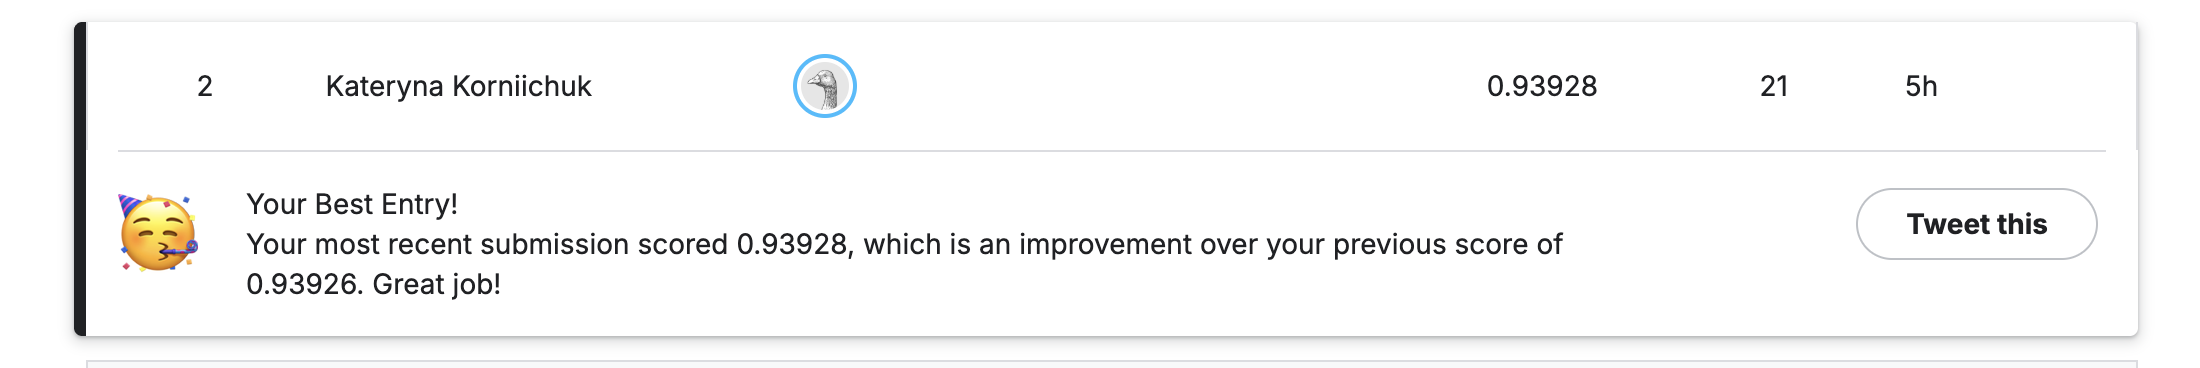

In [18]:
from IPython.display import Image, display

display(Image(filename='/content/Kaggle3.png'))